### 0. 데이터 분석전 버전확인 및 라이브러리 설치


In [1]:

import sys
from pathlib import Path
import numpy as np
import pandas as pd

print("Python executable:", sys.executable)
print("Python version:", sys.version)
print("Current working directory:", Path.cwd())
print("pandas:", pd.__version__)
print("numpy:", np.__version__)

Python executable: c:\dev\llm_data_analysis-course\.venv\Scripts\python.exe
Python version: 3.14.7 (tags/v3.14.7:823f032, Aug  5 2026, 10:51:32) [MSC v.1944 64 bit (AMD64)]
Current working directory: c:\dev\llm_data_analysis-course\notebooks
pandas: 3.0.5
numpy: 2.5.2


In [2]:
import pandas as pd
from pathlib import Path

PROJECT_ROOT = Path.cwd()

while not (PROJECT_ROOT / "data" / "titanic").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_PATH = PROJECT_ROOT / "data" / "titanic" / "train.csv"

df = pd.read_csv(DATA_PATH)
df_work = df.copy()

print(df_work.shape)
df_work.head()

(891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


기본 라이브러리 실행 오류 여부 확인

현재 Python: 3.14.7

현재 Notebook Kernel:

현재 작업 폴더: c:\dev\llm_data_analysis-course\notebooks

확인한 패키지: pandas: 3.0.5, numpy: 2.5.2

환경에서 추가로 확인할 점: 없음

### STEP 02. Titanic 데이터 확보와 로딩
02_1 프로젝트 루트 찾기

In [3]:
from pathlib import Path

def get_project_root(start_path: Path | None = None) -> Path:
    """현재 위치에서 상위 폴더를 탐색해 data 폴더가 있는 프로젝트 루트를 찾는다."""
    current = (start_path or Path.cwd()).resolve()
    for path in (current, *current.parents):
        if (path / "data").is_dir():
            return path
    raise FileNotFoundError("data 폴더가 있는 프로젝트 루트를 찾을 수 없습니다.")

project_root = get_project_root()
data_path = project_root / "data" / "titanic" / "train.csv"

if not data_path.exists():
    raise FileNotFoundError(
        f"Titanic 데이터가 없습니다: {data_path}\n"
        "저장소 루트에서 python scripts/prepare_titanic_data.py 를 먼저 실행하세요."
    )


print(get_project_root)

print(data_path)

<function get_project_root at 0x0000029226BFCCA0>
C:\dev\llm_data_analysis-course\data\titanic\train.csv


프로젝트 root 및 데이터 파일 경로 가져오기 성공

02_2 데이터 로딩

In [4]:
import pandas as pd

df = pd.read_csv(data_path)


print("data path:", data_path)
print("shape:", df.shape)
print("columns:", df.columns.tolist())
df.head()


data path: C:\dev\llm_data_analysis-course\data\titanic\train.csv
shape: (891, 12)
columns: ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### STEP 03. 데이터 구조와 품질의 첫인상 확인

03_1. 크기와 앞부분 확인


In [5]:
print("shape:", df.shape)

df.head()

shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


03_2. dtype과 기본 구조 확인

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


어떤 컬럼이 숫자형인가?

어떤 컬럼이 문자열인가?

숫자로 저장되어 있지만 실제 의미는 범주형인 컬럼이 있는가?

결측치가 보이는가?


02_3. 결측치 요약

In [7]:
missing_count = df.isna().sum()
missing_rate = (df.isna().mean() * 100).round(2)
missing_summary = pd.DataFrame({
    "missing_count": missing_count,
    "missing_rate_pct": missing_rate,
}).sort_values("missing_count", ascending=False)
missing_summary

,missing_count,missing_rate_pct
Cabin,687,77.10
Age,177,19.87
Embarked,2,0.22
PassengerId,0,0.00
Name,0,0.00
Pclass,0,0.00
Survived,0,0.00
Sex,0,0.00
Parch,0,0.00
SibSp,0,0.00


03_4. 중복과 기초 통계

In [8]:
print("duplicate rows:", df.duplicated().sum())

df.describe(include="all")

duplicate rows: 0


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
count,891.000000,891.000000,891.000000,891,891,714.000000,891.000000,891.000000,891,891.000000,204,889
unique,NaN,NaN,NaN,891,2,NaN,NaN,NaN,681,NaN,147,3
top,NaN,NaN,NaN,"Braund, Mr. Owen Harris",male,NaN,NaN,NaN,347082,NaN,G6,S
freq,NaN,NaN,NaN,1,577,NaN,NaN,NaN,7,NaN,4,644
mean,446.000000,0.383838,2.308642,NaN,NaN,29.699118,0.523008,0.381594,NaN,32.204208,NaN,NaN
std,257.353842,0.486592,0.836071,NaN,NaN,14.526497,1.102743,0.806057,NaN,49.693429,NaN,NaN
min,1.000000,0.000000,1.000000,NaN,NaN,0.420000,0.000000,0.000000,NaN,0.000000,NaN,NaN
25%,223.500000,0.000000,2.000000,NaN,NaN,20.125000,0.000000,0.000000,NaN,7.910400,NaN,NaN
50%,446.000000,0.000000,3.000000,NaN,NaN,28.000000,0.000000,0.000000,NaN,14.454200,NaN,NaN
75%,668.500000,1.000000,3.000000,NaN,NaN,38.000000,1.000000,0.000000,NaN,31.000000,NaN,NaN


★ 개인 판단 지점 1

- PassengerId 중복 여부
- Age 범위 : 
- Fare 이상치 : 
- 각 범주형 컬럼의 unique 개수
- Sex / Embarked / Pclass의 값 분포

## AI Prompt 예시

현재 STEP 03 실행 결과를 기준으로
추가로 확인할 가치가 있는 데이터 품질 분석 후보 3개를 제안해 주세요.
각 후보에 대해
1. 무엇을 확인하는지
2. 왜 필요한지
3. 결과에 따라 다음 판단이 어떻게 달라지는지
를 설명해 주세요.
아직 코드는 작성하지 마세요.

### STEP 04. 분석 문제와 Target 정의

04_1. Target 확인

In [9]:
print("Survived missing:", df["Survived"].isna().sum())
print("Survived unique:", sorted(df["Survived"].dropna().unique()))

print("\nClass count")
print(df["Survived"].value_counts().sort_index())

print("\nClass ratio")
print(df["Survived"].value_counts(normalize=True).sort_index())

Survived missing: 0
Survived unique: [np.int64(0), np.int64(1)]

Class count
Survived
0    549
1    342
Name: count, dtype: int64

Class ratio
Survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64


In [10]:
import pandas as pd
from pathlib import Path

PROJECT_ROOT = Path.cwd()

while not (PROJECT_ROOT / "data" / "titanic").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_PATH = PROJECT_ROOT / "data" / "titanic" / "train.csv"

df = pd.read_csv(DATA_PATH)
df_work = df.copy()

print("데이터 경로:", DATA_PATH)
print("shape:", df_work.shape)

df_work.head()

데이터 경로: c:\dev\llm_data_analysis-course\data\titanic\train.csv
shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


# 타이타닉 데이터프레임 컬럼 설명

| 컬럼명 | 의미 |
|---|---|
| `PassengerId` | 승객 번호 |
| `Survived` | 생존 여부 (`0` = 사망, `1` = 생존) |
| `Pclass` | 객실 등급 (`1` = 1등석, `2` = 2등석, `3` = 3등석) |
| `Name` | 승객 이름 |
| `Sex` | 성별 (`male` = 남성, `female` = 여성) |
| `Age` | 나이 |
| `SibSp` | 함께 탑승한 형제·자매 또는 배우자 수 |
| `Parch` | 함께 탑승한 부모 또는 자녀 수 |
| `Ticket` | 티켓 번호 |
| `Fare` | 티켓 요금 |
| `Cabin` | 객실 번호 |
| `Embarked` | 탑승한 항구 |

## Embarked 값

- `C` = Cherbourg(셰르부르)
- `Q` = Queenstown(퀸스타운)
- `S` = Southampton(사우샘프턴)

Survived가 0과 1 두 범주이므로 이번 문제는 기본적으로 이진 분류(Binary Classification) 문제입니다.

04_02. Feature와 Target

Feature = 예측에 사용할 입력 정보
Target  = 맞히고 싶은 정답

예를 들어 Sex, Pclass, Age, Fare 등은 Feature 후보가 될 수 있고 Survived는 Target입니다.

04_03. 데이터 누수의 첫 질문

결측치 다시 확인

In [11]:
missing_summary = pd.DataFrame({
    "count": df_work.isna().sum(),
    "rate_pct": (df_work.isna().mean() * 100).round(2),
}).sort_values("count", ascending=False)

missing_summary

,count,rate_pct
Cabin,687,77.10
Age,177,19.87
Embarked,2,0.22
PassengerId,0,0.00
Name,0,0.00
Pclass,0,0.00
Survived,0,0.00
Sex,0,0.00
Parch,0,0.00
SibSp,0,0.00


In [12]:
df_work[["Age", "Embarked", "Cabin"]].isna().sum()

Age         177
Embarked      2
Cabin       687
dtype: int64

### STEP 06. 불필요한 컬럼 검토

KEEP    = 그대로 사용할 후보

EXCLUDE = 모델 입력에서는 제외할 후보

DERIVE  = 새로운 Feature를 만들 재료

DEFER   = 지금 결정하지 않고 보류

In [13]:
for col in ["Sex", "Embarked", "Pclass"]:

    print(f"\n[{col}]")
    print(df_work[col].value_counts(dropna=False))


[Sex]
Sex
male      577
female    314
Name: count, dtype: int64

[Embarked]
Embarked
S      644
C      168
Q       77
NaN      2
Name: count, dtype: int64

[Pclass]
Pclass
3    491
1    216
2    184
Name: count, dtype: int64


교육용 인코딩 branch

In [14]:
df_encoded = df_work.copy()

In [15]:
df_encoded["SexMapped"] = df_encoded["Sex"].map({
    "male": 0,
    "female": 1,
})

df_encoded[["Sex", "SexMapped"]].head()

,Sex,SexMapped
0,male,0
1,female,1
2,female,1
3,female,1
4,male,0


## One-Hot Encoding 예시

In [16]:
embarked_dummies = pd.get_dummies(
    df_encoded["Embarked"],
    prefix="Embarked",
    dtype=int,
)

embarked_dummies.head()

,Embarked_C,Embarked_Q,Embarked_S
0,0,0,1
1,1,0,0
2,0,0,1
3,0,0,1
4,0,0,1


### STEP 08. 시각화와 기본 패턴 확인

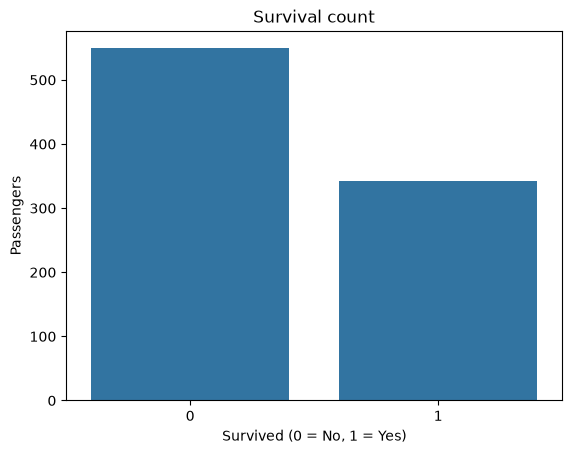

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns


sns.countplot(data=df_work, x="Survived")
plt.title("Survival count")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Passengers")
plt.show()

관찰: 사망자 수와 생존자 수 비율

해석: 사망자수가 많다

추가 확인:

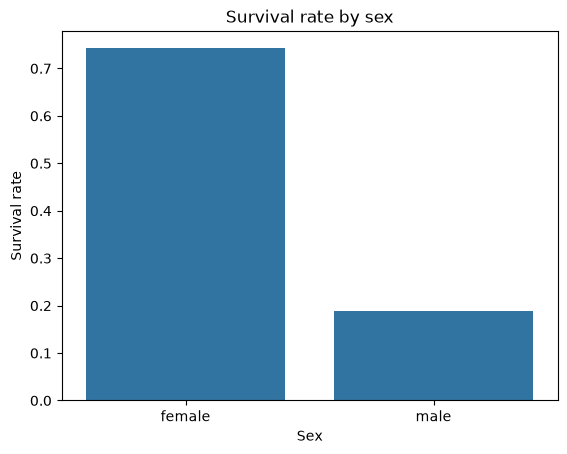

In [18]:
sex_survival = (
    df_work.groupby("Sex", as_index=False)["Survived"]
    .mean()
)

sns.barplot(data=sex_survival, x="Sex", y="Survived")
plt.title("Survival rate by sex")
plt.ylabel("Survival rate")
plt.show()

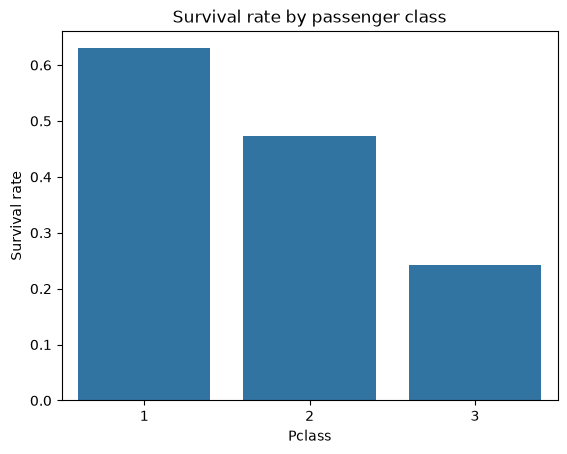

In [19]:
pclass_survival = (
    df_work.groupby("Pclass", as_index=False)["Survived"]
    .mean()
)


sns.barplot(data=pclass_survival, x="Pclass", y="Survived")
plt.title("Survival rate by passenger class")
plt.ylabel("Survival rate")
plt.show()

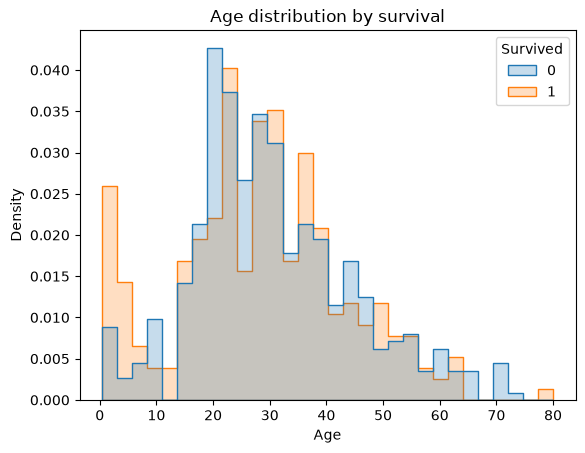

In [20]:
sns.histplot(
    data=df_work,
    x="Age",
    hue="Survived",
    bins=30,
    element="step",
    stat="density",
    common_norm=False,
)

plt.title("Age distribution by survival")
plt.show()

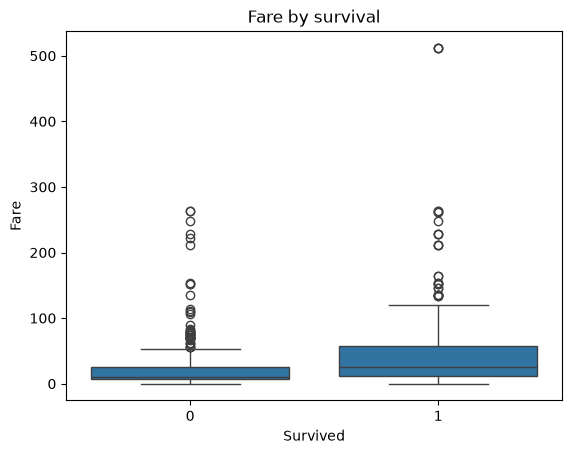

In [21]:
sns.boxplot(data=df_work, x="Survived", y="Fare")
plt.title("Fare by survival")
plt.xlabel("Survived")
plt.ylabel("Fare")
plt.show()

In [22]:
df_work.loc[
    df_work["Name"].str.contains("", case=False, na=False),
    ["PassengerId", "Name", "Sex", "Age", "Pclass", "Fare", "Survived"]
]

,PassengerId,Name,Sex,Age,Pclass,Fare,Survived
0,1,"Braund, Mr. Owen Harris",male,22.0,3,7.2500,0
1,2,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,71.2833,1
2,3,"Heikkinen, Miss Laina",female,26.0,3,7.9250,1
3,4,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,53.1000,1
4,5,"Allen, Mr. William Henry",male,35.0,3,8.0500,0
...,...,...,...,...,...,...,...
886,887,"Montvila, Rev. Juozas",male,27.0,2,13.0000,0
887,888,"Graham, Miss Margaret Edith",female,19.0,1,30.0000,1
888,889,"Johnston, Miss Catherine Helen ""Carrie""",female,NaN,3,23.4500,0
889,890,"Behr, Mr. Karl Howell",male,26.0,1,30.0000,1


질문 2. 성별에 따라 생존율이 다른가?

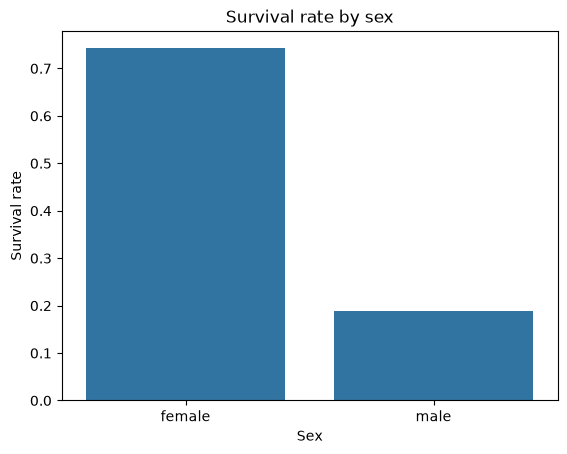

In [23]:
sex_survival = (
    df_work.groupby("Sex", as_index=False)["Survived"]
    .mean()
)

sns.barplot(data=sex_survival, x="Sex", y="Survived")
plt.title("Survival rate by sex")
plt.ylabel("Survival rate")
plt.show()

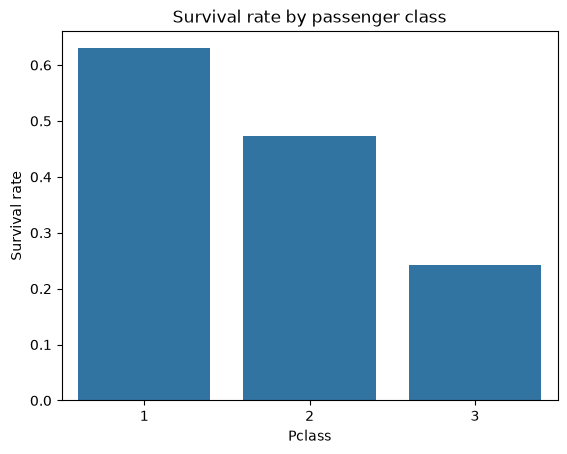

In [24]:
pclass_survival = (
    df_work.groupby("Pclass", as_index=False)["Survived"]
    .mean()
)

sns.barplot(data=pclass_survival, x="Pclass", y="Survived")
plt.title("Survival rate by passenger class")
plt.ylabel("Survival rate")
plt.show()

In [25]:
feature_demo = df_work.copy()
feature_demo["FamilySize"] = feature_demo["SibSp"] + feature_demo["Parch"] + 1
feature_demo["IsAlone"] = (feature_demo["FamilySize"] == 1).astype(int)
display(feature_demo[["SibSp", "Parch", "FamilySize", "IsAlone", "Survived"]].head())

,SibSp,Parch,FamilySize,IsAlone,Survived
0,1,0,2,0,0
1,1,0,2,0,1
2,0,0,1,1,1
3,1,0,2,0,1
4,0,0,1,1,0


In [26]:
print("project_root:", project_root)

src_path = project_root / "src"

print("src_path:", src_path)
print("src 폴더 존재:", src_path.exists())

project_root: C:\dev\llm_data_analysis-course
src_path: C:\dev\llm_data_analysis-course\src
src 폴더 존재: False


In [27]:
from sklearn.model_selection import train_test_split

# 모델에 사용할 컬럼 정의
NUMERIC_FEATURES = [
    "Pclass",
    "Age",
    "SibSp",
    "Parch",
    "Fare"
]

CATEGORICAL_FEATURES = [
    "Sex",
    "Embarked"
]

MODEL_FEATURE_COLUMNS = (
    NUMERIC_FEATURES
    + CATEGORICAL_FEATURES
)

# 필요한 데이터만 복사
model_source = df_work.copy()

X = model_source[MODEL_FEATURE_COLUMNS].copy()
y = model_source["Survived"].astype(int).copy()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("train:", X_train.shape, y_train.shape)
print("test :", X_test.shape, y_test.shape)

display(
    y_train.value_counts(normalize=True)
    .sort_index()
    .rename("train_ratio")
    .to_frame()
)

display(
    y_test.value_counts(normalize=True)
    .sort_index()
    .rename("test_ratio")
    .to_frame()
)

train: (712, 7) (712,)
test : (179, 7) (179,)


,train_ratio
Survived,
0,0.616573
1,0.383427


,test_ratio
Survived,
0,0.614525
1,0.385475


In [28]:
model_source = feature_demo.copy()

In [29]:
model_source.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
 12  FamilySize   891 non-null    int64  
 13  IsAlone      891 non-null    int64  
dtypes: float64(2), int64(7), str(5)
memory usage: 97.6 KB


In [30]:
feature_columns = [
    "Pclass",
    "Sex",
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "Embarked",
    "FamilySize",
    "IsAlone",
]

In [66]:
raw_input_columns = [
    "PassengerId",
    "Pclass",
    "Name",
    "Sex",
    "Age",
    "SibSp",
    "Parch",
    "Ticket",
    "Fare",
    "Cabin",
    "Embarked"
]

feature_columns = [
    "Pclass",
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "Sex",
    "Embarked"
]

In [67]:
numeric_features = [
    "Pclass",
    "Age",
    "SibSp",
    "Parch",
    "Fare"
]

categorical_features = [
    "Sex",
    "Embarked"
]

In [31]:
from sklearn.impute import SimpleImputer

numeric_features = [
    "Pclass",
    "Age",
    "SibSp",
    "Parch",
    "Fare"
]

numeric_imputer = SimpleImputer(strategy="median")

X_train_num_imputed = pd.DataFrame(
    numeric_imputer.fit_transform(
        X_train[numeric_features]
    ),
    columns=numeric_features,
    index=X_train.index,
)

X_test_num_imputed = pd.DataFrame(
    numeric_imputer.transform(
        X_test[numeric_features]
    ),
    columns=numeric_features,
    index=X_test.index,
)

X_train_num_imputed.head()

,Pclass,Age,SibSp,Parch,Fare
692,3.0,28.5,0.0,0.0,56.4958
481,2.0,28.5,0.0,0.0,0.0000
527,1.0,28.5,0.0,0.0,221.7792
855,3.0,18.0,0.0,1.0,9.3500
801,2.0,31.0,1.0,1.0,26.2500


In [32]:
model_source[["FamilySize", "IsAlone"]]

,FamilySize,IsAlone
0,2,0
1,2,0
2,1,1
3,2,0
4,1,1
...,...,...
886,1,1
887,1,1
888,4,0
889,1,1


In [33]:
from sklearn.impute import SimpleImputer

categorical_features = [
    "Sex",
    "Embarked"
]

categorical_imputer = SimpleImputer(strategy="most_frequent")

X_train_cat_imputed = pd.DataFrame(
    categorical_imputer.fit_transform(
        X_train[categorical_features]
    ),
    columns=categorical_features,
    index=X_train.index,
)

X_test_cat_imputed = pd.DataFrame(
    categorical_imputer.transform(
        X_test[categorical_features]
    ),
    columns=categorical_features,
    index=X_test.index,
)

X_train_cat_imputed.head()

,Sex,Embarked
692,male,S
481,male,S
527,male,S
855,female,S
801,female,S


In [34]:
X = model_source[feature_columns].copy()
y = model_source["Survived"].astype(int).copy()

print("X:", X.shape)
print("y:", y.shape)

display(X.head())
display(y.head())

X: (891, 9)
y: (891,)


,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,FamilySize,IsAlone
0,3,male,22.0,1,0,7.2500,S,2,0
1,1,female,38.0,1,0,71.2833,C,2,0
2,3,female,26.0,0,0,7.9250,S,1,1
3,1,female,35.0,1,0,53.1000,S,2,0
4,3,male,35.0,0,0,8.0500,S,1,1


0    0
1    1
2    1
3    1
4    0
Name: Survived, dtype: int64

In [35]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y,
)

In [36]:
print("train:", X_train.shape, y_train.shape)
print("test :", X_test.shape, y_test.shape)

train: (712, 9) (712,)
test : (179, 9) (179,)


In [37]:
print("전체 데이터")
display(
    y.value_counts(normalize=True)
     .sort_index()
     .rename("ratio")
     .to_frame()
)

print("학습 데이터")
display(
    y_train.value_counts(normalize=True)
           .sort_index()
           .rename("train_ratio")
           .to_frame()
)

print("테스트 데이터")
display(
    y_test.value_counts(normalize=True)
          .sort_index()
          .rename("test_ratio")
          .to_frame()
)

전체 데이터


,ratio
Survived,
0,0.616162
1,0.383838


학습 데이터


,train_ratio
Survived,
0,0.616573
1,0.383427


테스트 데이터


,test_ratio
Survived,
0,0.614525
1,0.385475


In [38]:
X = model_source[feature_columns].copy()
y = model_source["Survived"].astype(int).copy()

In [39]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y,
)

In [40]:
categorical_imputer = SimpleImputer(strategy="most_frequent")
X_train_cat_imputed = pd.DataFrame(
    categorical_imputer.fit_transform(X_train[categorical_features]),
    columns=categorical_features,
    index=X_train.index,
)

X_test_cat_imputed = pd.DataFrame(
    categorical_imputer.transform(X_test[categorical_features]),
    columns=categorical_features,
    index=X_test.index,
)

In [41]:

from sklearn.impute import SimpleImputer

numeric_imputer = SimpleImputer(strategy="median")
X_train_num_imputed = pd.DataFrame(
    numeric_imputer.fit_transform(X_train[numeric_features]),
    columns=numeric_features,
    index=X_train.index,
)

X_test_num_imputed = pd.DataFrame(
    numeric_imputer.transform(X_test[numeric_features]),
    columns=numeric_features,
    index=X_test.index,
)

In [42]:
from sklearn.preprocessing import MinMaxScaler

minmax_demo = MinMaxScaler()

minmax_preview = pd.DataFrame(

    minmax_demo.fit_transform(

        X_train_num_imputed[["Age", "Fare"]]

    ),

    columns=["Age_minmax", "Fare_minmax"],

    index=X_train.index,

)

display(minmax_preview.head())

,Age_minmax,Fare_minmax
692,0.352852,0.110272
481,0.352852,0.000000
527,0.352852,0.432884
855,0.220910,0.018250
801,0.384267,0.051237


In [43]:
model_source.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,FamilySize,IsAlone
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,2,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,2,0
2,3,1,3,"Heikkinen, Miss Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,1,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,2,0
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,1,1


In [49]:
from sklearn.preprocessing import OneHotEncoder
import pandas as pd

# 범주형 컬럼
categorical_features = [
    "Sex",
    "Embarked"
]

# 결측치 처리된 범주형 데이터가 이미 있다는 전제
encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

# train에서는 fit_transform
X_train_cat_encoded_array = encoder.fit_transform(
    X_train_cat_imputed[categorical_features]
)

# test에서는 transform
X_test_cat_encoded_array = encoder.transform(
    X_test_cat_imputed[categorical_features]
)

# 새 컬럼명 생성
encoded_columns = encoder.get_feature_names_out(
    categorical_features
)

# DataFrame으로 변환
X_train_cat_encoded = pd.DataFrame(
    X_train_cat_encoded_array,
    columns=encoded_columns,
    index=X_train.index
)

X_test_cat_encoded = pd.DataFrame(
    X_test_cat_encoded_array,
    columns=encoded_columns,
    index=X_test.index
)

display(X_train_cat_encoded.head())

,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
692,0.0,1.0,0.0,0.0,1.0
481,0.0,1.0,0.0,0.0,1.0
527,0.0,1.0,0.0,0.0,1.0
855,1.0,0.0,0.0,0.0,1.0
801,1.0,0.0,0.0,0.0,1.0


표준화 정규화
# MinMaxScaler
데이터에서 가장 큰 값과 작은 값을 각각 1과 0으로 잡고 0 ~ 1 사이의 수로 표시함

정규화 Normalization
대표 예: MinMaxScaler
→ 값을 보통 0~1 범위로 맞춤

표준화 Standardization
대표 예: StandardScaler

→ 평균 0, 표준편차 1을 기준으로 맞춤

In [44]:
from sklearn.preprocessing import MinMaxScaler

minmax_demo = MinMaxScaler()
minmax_preview = pd.DataFrame(
    minmax_demo.fit_transform(
        X_train_num_imputed[["Age", "Fare"]]
    ),
    
    columns=["Age_minmax", "Fare_minmax"],
    index=X_train.index,
)

display(minmax_preview.head())

,Age_minmax,Fare_minmax
692,0.352852,0.110272
481,0.352852,0.000000
527,0.352852,0.432884
855,0.220910,0.018250
801,0.384267,0.051237


In [45]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_num_scaled = pd.DataFrame(
    scaler.fit_transform(X_train_num_imputed),

    columns=numeric_features,
    index=X_train.index,
)

X_test_num_scaled = pd.DataFrame(
    scaler.transform(X_test_num_imputed),

    columns=numeric_features,
    index=X_test.index,
)

In [51]:
X_train_ready = pd.concat(
    [
        X_train_num_scaled,
        X_train_cat_encoded
    ],
    axis=1
)

X_test_ready = pd.concat(
    [
        X_test_num_scaled,
        X_test_cat_encoded
    ],
    axis=1
)

print("X_train_ready:", X_train_ready.shape)
print("X_test_ready :", X_test_ready.shape)

X_train_ready.head()

X_train_ready: (712, 10)
X_test_ready : (179, 10)


,Pclass,Age,SibSp,Parch,Fare,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
692,0.829568,-0.081135,-0.465084,-0.466183,0.513812,0.0,1.0,0.0,0.0,1.0
481,-0.370945,-0.081135,-0.465084,-0.466183,-0.662563,0.0,1.0,0.0,0.0,1.0
527,-1.571457,-0.081135,-0.465084,-0.466183,3.955399,0.0,1.0,0.0,0.0,1.0
855,0.829568,-0.887827,-0.465084,0.727782,-0.467874,1.0,0.0,0.0,0.0,1.0
801,-0.370945,0.110934,0.478335,0.727782,-0.115977,1.0,0.0,0.0,0.0,1.0


In [52]:
print("X_train_ready:", X_train_ready.shape)
print("X_test_ready :", X_test_ready.shape)
print("missing train:", X_train_ready.isna().sum().sum())
print("missing test :", X_test_ready.isna().sum().sum())


X_train_ready: (712, 10)
X_test_ready : (179, 10)
missing train: 0
missing test : 0


Logistic Regression Baseline


In [56]:
from sklearn.linear_model import LogisticRegression

baseline_model = LogisticRegression(
    max_iter=1000,
    random_state=42,
)

baseline_model.fit(X_train_ready, y_train);

In [57]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
)

baseline_pred = baseline_model.predict(X_test_ready)

print("accuracy :", round(accuracy_score(y_test, baseline_pred), 4))
print("precision:", round(precision_score(y_test, baseline_pred), 4))
print("recall   :", round(recall_score(y_test, baseline_pred), 4))
print("f1       :", round(f1_score(y_test, baseline_pred), 4))

accuracy : 0.8045
precision: 0.7931
recall   : 0.6667
f1       : 0.7244


In [58]:
cm = confusion_matrix(y_test, baseline_pred, labels=[0, 1])
tn, fp, fn, tp = cm.ravel()

print(cm)
print({"TN": tn, "FP": fp, "FN": fn, "TP": tp})

[[98 12]
 [23 46]]
{'TN': np.int64(98), 'FP': np.int64(12), 'FN': np.int64(23), 'TP': np.int64(46)}


In [59]:
from sklearn.ensemble import RandomForestClassifier

additional_model = RandomForestClassifier(
    n_estimators=300,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1,
)

additional_model.fit(X_train_ready, y_train)
additional_pred = additional_model.predict(X_test_ready)

In [60]:
model_compare = pd.DataFrame([
    {
        "model": "Logistic Regression",
        "accuracy": accuracy_score(y_test, baseline_pred),
        "f1": f1_score(y_test, baseline_pred),
    },

    {
        "model": "Random Forest",
        "accuracy": accuracy_score(y_test, additional_pred),
        "f1": f1_score(y_test, additional_pred),
    },

])

display(model_compare)

,model,accuracy,f1
0,Logistic Regression,0.804469,0.724409
1,Random Forest,0.804469,0.715447


In [62]:
FINAL_MODEL_CHOICE = "baseline"
if FINAL_MODEL_CHOICE == "baseline":
    final_model = baseline_model
    final_model_name = "Logistic Regression"
elif FINAL_MODEL_CHOICE == "random_forest":
    final_model = additional_model
    final_model_name = "Random Forest"
else:
    raise ValueError("baseline 또는 random_forest를 선택하세요.")

In [63]:
import json
import joblib

models_dir = project_root / "models"
models_dir.mkdir(parents=True, exist_ok=True)
bundle_path = models_dir / "titanic_model_bundle.joblib"
contract_path = models_dir / "titanic_model_contract.json"
model_bundle = {
    "numeric_imputer": numeric_imputer,
    "categorical_imputer": categorical_imputer,
    "encoder": encoder,
    "scaler": scaler,
    "model": final_model,
}

joblib.dump(model_bundle, bundle_path)

['C:\\dev\\llm_data_analysis-course\\models\\titanic_model_bundle.joblib']

In [68]:
model_contract = {

    "task": "binary_classification",

    "target": "Survived",

    "positive_class": 1,

    "raw_input_columns": raw_input_columns,

    "model_feature_columns": feature_columns,

    "numeric_features": numeric_features,

    "categorical_features": categorical_features,

    "prepared_feature_columns": X_train_ready.columns.tolist(),

    "derived_features": ["FamilySize", "IsAlone"],

    "scaling": "StandardScaler",

    "final_estimator": type(final_model).__name__,

}

In [69]:
import json
from pathlib import Path

PROJECT_ROOT = Path.cwd()

while not (PROJECT_ROOT / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

MODELS_DIR = PROJECT_ROOT / "models"
MODELS_DIR.mkdir(exist_ok=True)

contract_path = MODELS_DIR / "titanic_model_contract.json"

with open(contract_path, "w", encoding="utf-8") as f:
    json.dump(
        model_contract,
        f,
        ensure_ascii=False,
        indent=2
    )

print("저장 완료:", contract_path)

저장 완료: c:\dev\llm_data_analysis-course\models\titanic_model_contract.json


In [70]:
import joblib

model_path = MODELS_DIR / "titanic_model.joblib"

joblib.dump(final_model, model_path)

print("모델 저장 완료:", model_path)

모델 저장 완료: c:\dev\llm_data_analysis-course\models\titanic_model.joblib
